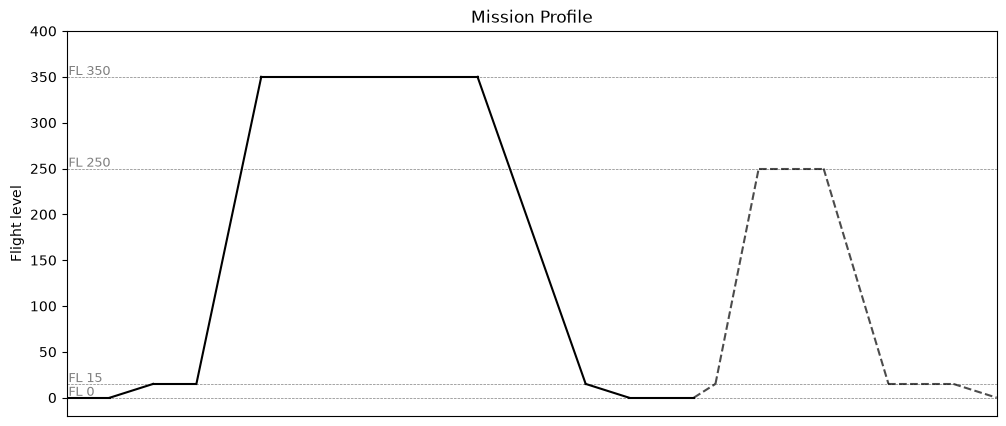

In [425]:
import numpy as np
import csv
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

LHV_H2 = 119.96 #MJ/kg
LHV_jetA = 44.1 #MJ/kg
LHV_ratio = LHV_H2 / LHV_jetA
M_crs_speed = 0.85 #Mach
range = 12500e+3 #m

# (W_empty / W_0) = (W_empty / W_0)_plotfit + (W_tank/W_0) 
#W_tank calculated from G_i


#Requirements?
#PAX>350, High BPR. 
with open("Data/JMPInputSheetFANS.csv", "r", encoding="utf-8-sig", newline="") as csvfile:
    reader = csv.DictReader(csvfile)
    data = list(reader)

Aircraft = [row["AircraftDesignation"] for row in data]
Aircraft_name = [row["AircraftDesignation"] for row in data]
EIS = [
    int(row["TLAR_EIS"]) if row["TLAR_EIS"].strip() else np.nan
    for row in data
]

Aircraft_Passengers = [
    int(row["TLAR_MaxPax"]) if row["TLAR_MaxPax"].strip() else np.nan
    for row in data
]

Engine_EIS = [
    int(row["Engine_EIS"]) if row["Engine_EIS"].strip() else np.nan
    for row in data 
]

Engine_BPR = [
    float(row["Engine_BPR"]) if row["Engine_BPR"].strip() else np.nan
    for row in data
]

Engine_crs_SFC = [
    float(row["Engine_TSFC_Crs"])*2.831969e1 if row["Engine_TSFC_Crs"].strip() else np.nan
    for row in data
] 
# Conversion factor: 1 lb = 0.453592 kg, 1 lbf = 4.44822 N, 1 hr = 3600 s. So 1 lb/lbf/hr = 0.453592/4.44822/3600 kg/N/s = 2.831969e-5 kg/N/s

#Maybe add Maximum takeoff weight and range to the requirements?


#Plot mission profile.
mission_profile = True

if mission_profile:

    flight_level_markings = [0, 15, 250, 350]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_ylim(-20, 400)
    ax.set_xlim(0, 43)
    ax.set_xticks([])
    ax.set_title("Mission Profile", fontsize=12)
    ax.set_ylabel("Flight level", fontsize=10)

    for level in flight_level_markings:
        ax.axhline(level, color="gray", linestyle="--", linewidth=0.5)
        ax.text(0.08, level + 2, f"FL {level}", fontsize=9, color="gray")

    #Start up and taxi
    y = 0
    x = np.linspace(0, 2, 100)
    ax.plot(x, y*np.ones_like(x), label="Start up and taxi", color="black")

    #Take off
    x = np.linspace(2, 4, 100)
    y = np.linspace(0, 15, 100)
    ax.plot(x, y, label="Take off", color="black")

    #initial climb
    x = np.linspace(4, 6, 100)
    y = 15
    ax.plot(x, y*np.ones_like(x), label="Initial climb", color="black")

    #Climb
    x = np.linspace(6, 9, 100)
    y = np.linspace(15, 350, 100)
    ax.plot(x, y, label="Climb", color="black")

    #Cruise
    x = np.linspace(9, 19, 100)
    y = 350
    ax.plot(x, y*np.ones_like(x), label="Cruise", color="black")

    #Descent
    x = np.linspace(19, 24, 100)
    y = np.linspace(350, 15, 100)
    ax.plot(x, y, label="Descent", color="black")

    #Approach and landing
    x = np.linspace(24, 26, 100)
    y = np.linspace(15, 0, 100)
    ax.plot(x, y, label="Approach and landing", color="black")

    #Taxi and shutdown + contingency (3%)
    x = np.linspace(26, 29, 100)
    y = 0
    ax.plot(x, y*np.ones_like(x), label="Taxi and shutdown", color="black")

    #Missed approach/Go-around/Diversion 
    x = np.linspace(29, 30, 100)
    y = np.linspace(0, 15, 100)
    ax.plot(x, y, label="Missed approach/Go-around/Diversion", color="black", linestyle="--", alpha=0.7)

    #Diversion climb
    x = np.linspace(30, 32, 100)
    y = np.linspace(15, 250, 100)
    ax.plot(x, y, label="Diversion climb", color="black", linestyle="--", alpha=0.7)

    #Diversion cruise
    x = np.linspace(32, 35, 100)
    y = 250
    ax.plot(x, y*np.ones_like(x), label="Diversion cruise", color="black", linestyle="--", alpha=0.7)

    #Diversion descent
    x = np.linspace(35, 38, 100)
    y = np.linspace(250, 15, 100)
    ax.plot(x, y, label="Diversion descent", color="black", linestyle="--", alpha=0.7)

    #Hold 
    x = np.linspace(38, 41, 100)
    y = 15
    ax.plot(x, y*np.ones_like(x), label="Hold", color="black", linestyle="--", alpha=0.7)

    #Diversion approach and landing
    x = np.linspace(41, 43, 100)
    y = np.linspace(15, 0, 100)
    ax.plot(x, y, label="Diversion approach and landing", color="black", linestyle="--", alpha=0.7)



5.445876387 0.03 13.528315913000002
Exponential fit RMSE: 0.7176, R^2: 0.7309
Linear fit RMSE: 0.7013, R^2: 0.7430
Predicted cruise SFC (Jet A) for 2050 using exponential fit: 12.25 mg/Ns
Predicted cruise SFC (Jet A) for 2050 using linear fit: 11.14 mg/Ns
Predicted loiter SFC (Jet A) for 2050 using exponential fit: 9.55 mg/Ns
Predicted cruise SFC (H2) for 2050 using exponential fit: 4.50 mg/Ns
Predicted cruise SFC (H2) for 2050 using linear fit: 4.10 mg/Ns
Predicted loiter SFC (H2) for 2050 using exponential fit: 3.51 mg/Ns


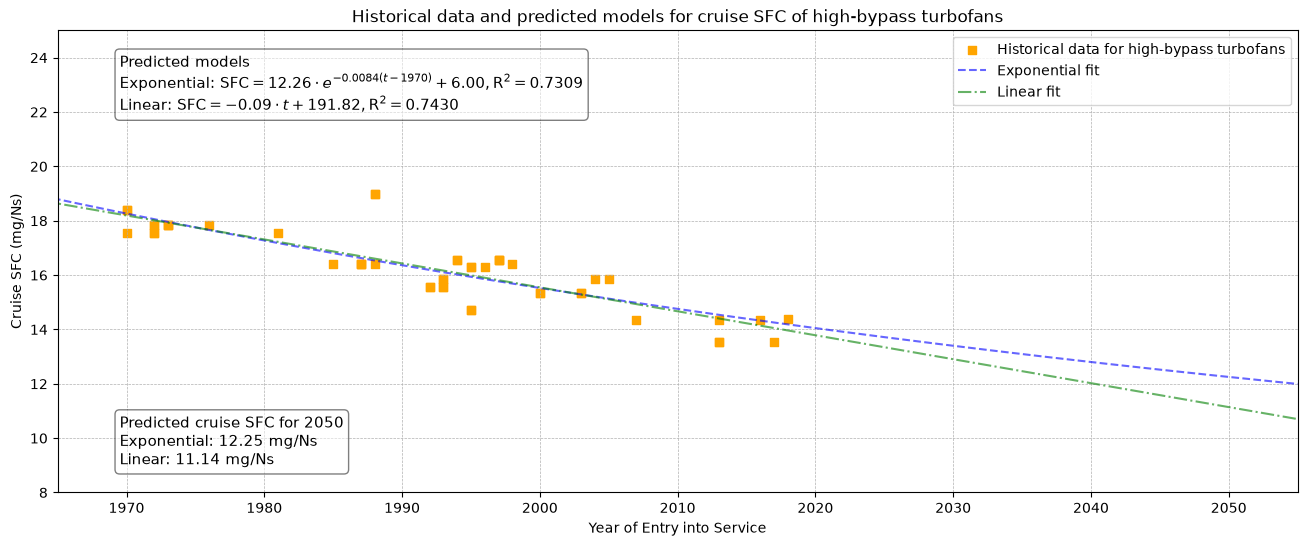

In [448]:
#SFC PREDICITON AND PLOTTING

SFC_plot = True #Flag to enable/disable SFC plotting.



#Cut data in Engine-cruise_SFC based on max passengers and BPR. 
Engine_crs_SFC_rq = []
EIS_rq = []
for tuple in enumerate(Engine_crs_SFC):
    #Tuple 0: Index, Tuple 1: SFC value
    if Aircraft_Passengers[tuple[0]] >= 340 and Engine_BPR[tuple[0]] >=5 and EIS[tuple[0]] not in [np.nan, 0]:
        if tuple[1] not in [np.nan, 0]:
            Engine_crs_SFC_rq.append(tuple[1])
    #     print("Aircraft", Aircraft_name[tuple[0]], "with SFC", tuple[1], "meets requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])
    # else:
    #     print("Aircraft", Aircraft_name[tuple[0]], "with SFC", tuple[1], "does not meet requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])

for tuple in enumerate(Engine_EIS):
    #tuple[0]: Index, tuple[1]: EIS value
    if Aircraft_Passengers[tuple[0]] >= 340 and Engine_BPR[tuple[0]] >=5 and EIS[tuple[0]] not in [np.nan, 0] and Engine_crs_SFC[tuple[0]] not in [np.nan, 0]:
        EIS_rq.append(tuple[1])
        #print("Aircraft", Aircraft_name[tuple[0]], "with EIS", tuple[1], "meets requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])
    #else:
        #print("Aircraft", Aircraft_name[tuple[0]], "with EIS", tuple[1], "does not meet requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])

        
#Sort the lists based on EIS_paxrq
# print(type(EIS_rq))
EIS_rq, Engine_crs_SFC_rq = zip(*sorted(zip(EIS_rq, Engine_crs_SFC_rq)))
EIS_rq, Engine_crs_SFC_rq = list(EIS_rq), list(Engine_crs_SFC_rq)
# print(EIS_rq)
# #print(len(EIS_rq))
# print(Engine_crs_SFC_rq)
# #print(len(Engine_crs_SFC_rq))




#Exponential model for curve fitting
t0 = np.min(EIS_rq)

def exp_model(t, a, b, c):
    return a * np.exp(-b * (t-t0)) + c

#Guesses for [a, b, c]
coefficent_guess = [1, 0.03, 9]
print(np.max(Engine_crs_SFC_rq)-np.min(Engine_crs_SFC_rq), 0.03, np.min(Engine_crs_SFC_rq))


# Fit the exponential model to the data
params, covariance = curve_fit(exp_model, EIS_rq, Engine_crs_SFC_rq, p0=coefficent_guess, maxfev=10000, bounds=([0, 0, 6], [15, 0.1, 12.5]))

# print("Fitted parameters: a =", params[0], ", b =", params[1], ", c =", params[2])
# print("Covariance matrix:\n", covariance)
years = np.linspace(1940, 2055, 300)
SFC_fit = exp_model(years, params[0], params[1], params[2])


#Linear fit for comparison
coefficients_deg1 = np.polyfit(EIS_rq, Engine_crs_SFC_rq, 1)
# coefficients_deg3 = np.polyfit(EIS_rq, Engine_crs_SFC_rq, 3)

poly1d = np.poly1d(coefficients_deg1)
# poly2d = np.poly1d(coefficients_deg3)

predicted_SFC_deg1 = poly1d(years)
# predicted_SFC_deg3 = poly2d(years)


#RMSE and R^2 for the exponential fit
residuals = Engine_crs_SFC_rq - exp_model(np.array(EIS_rq), params[0], params[1], params[2])
rmse = np.sqrt(np.mean(residuals**2))
r2 = 1 - (np.sum(residuals**2) / np.sum((Engine_crs_SFC_rq - np.mean(Engine_crs_SFC_rq))**2))
print(f"Exponential fit RMSE: {rmse:.4f}, R^2: {r2:.4f}")

#RMSE and R^2 for the linear fit
residuals_deg1 = Engine_crs_SFC_rq - poly1d(np.array(EIS_rq))
rmse_deg1 = np.sqrt(np.mean(residuals_deg1**2))
r2_deg1 = 1 - (np.sum(residuals_deg1**2) / np.sum((Engine_crs_SFC_rq - np.mean(Engine_crs_SFC_rq))**2))
print(f"Linear fit RMSE: {rmse_deg1:.4f}, R^2: {r2_deg1:.4f}")




#Predicting SFC for 2050 using the fitted models
SFC_2050_exp = exp_model(2050, params[0], params[1], params[2])
SFC_2050_deg1 = poly1d(2050)
print(f"Predicted cruise SFC (Jet A) for 2050 using exponential fit: {SFC_2050_exp:.2f} mg/Ns")
print(f"Predicted cruise SFC (Jet A) for 2050 using linear fit: {SFC_2050_deg1:.2f} mg/Ns")

#Scale for loiter via factor from lecture notes. 
loiter_factor = 11.3/14.5
SFC_2050_loiter = SFC_2050_exp * loiter_factor
print(f"Predicted loiter SFC (Jet A) for 2050 using exponential fit: {SFC_2050_loiter:.2f} mg/Ns")

#Convert to H2 SFC using LHV ratio
SFC_H2_exp_crs = SFC_2050_exp / LHV_ratio 
SFC_H2_lin_crs = SFC_2050_deg1 / LHV_ratio
SFC_H2_exp_loiter = SFC_2050_loiter / LHV_ratio
print(f"Predicted cruise SFC (H2) for 2050 using exponential fit: {SFC_H2_exp_crs:.2f} mg/Ns")
print(f"Predicted cruise SFC (H2) for 2050 using linear fit: {SFC_H2_lin_crs:.2f} mg/Ns")
print(f"Predicted loiter SFC (H2) for 2050 using exponential fit: {SFC_H2_exp_loiter:.2f} mg/Ns")




#Plotting the data and the fitted curves
if SFC_plot:
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.set_xlabel("Year of Entry into Service")
    ax.set_ylabel("Cruise SFC (mg/Ns)")
    ax.set_ylim(8, 25)
    ax.set_xlim(1965, 2055)
    scatter = ax.scatter(EIS_rq, Engine_crs_SFC_rq, marker='s', color='orange', label="Historical data for high-bypass turbofans")
    ax.plot(years, SFC_fit, color='blue', label="Exponential fit", linestyle='--', alpha=0.6)
    ax.plot(years, predicted_SFC_deg1, color='green', label="Linear fit", linestyle='-.', alpha=0.6)
    ax.set_title("Historical data and predicted models for cruise SFC of high-bypass turbofans")
    ax.legend()
    eq_text = (
        "Predicted models\n"
        rf"Exponential: $\text{{SFC}} = {params[0]:.2f} \cdot e^{{-{params[1]:.4f}(t - {t0})}} + {params[2]:.2f},  \text{{R}}^2 = {r2:.4f}$" "\n"
        rf"Linear: $\text{{SFC}} = {coefficients_deg1[0]:.2f} \cdot t + {coefficients_deg1[1]:.2f},  \text{{R}}^2 = {r2_deg1:.4f}$"
    )
    ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    ax.text(0.05, 0.05, f"Predicted cruise SFC for 2050\nExponential: {SFC_2050_exp:.2f} mg/Ns\nLinear: {SFC_2050_deg1:.2f} mg/Ns", transform=ax.transAxes, fontsize=11, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

In [449]:
#WEIGHT FRACTION CALCULATION FOR HYDROGEN AIRCRAFT
LD_crs_350 = 17.5 #NEEDS TO BE ESTIMATED
LD_crs_250 = 15.5 #NEEDS TO BE ESTIMATED

#Warm up, taxi, and takeoff. Adjust for H2 using LHV ratio.
JetA_massfraction_TO = 0.97 #W_i/W(i-1)
JetA_fuel_consumption_TO = 1 - JetA_massfraction_TO
H2_fuel_consumption = JetA_fuel_consumption_TO / LHV_ratio
H2_massfraction_TO = 1 - H2_fuel_consumption
print(f"Warm-up, taxi, and takeoff: \n Jet A mass fraction: {JetA_massfraction_TO:.4f}, H2 mass fraction: {H2_massfraction_TO:.4f}")

#Climb. Adjust for H2 using LHV ratio.
JetA_massfraction_climb = 1.0065 - 0.0325*M_crs_speed #W_i/W(i-1)
JetA_fuel_consumption_climb = 1 - JetA_massfraction_climb
H2_fuel_consumption_climb = JetA_fuel_consumption_climb / LHV_ratio
H2_massfraction_climb = 1 - H2_fuel_consumption_climb
print(f"Climb: \n Jet A mass fraction: {JetA_massfraction_climb:.4f}, H2 mass fraction: {H2_massfraction_climb:.4f}")

#Approach and landing. Adjust for H2 using LHV ratio.
JetA_massfraction_AL = 0.995 #W_i/W(i-1)
JetA_fuel_consumption_AL = 1 - JetA_massfraction_AL
H2_fuel_consumption_AL = JetA_fuel_consumption_AL / LHV_ratio
H2_massfraction_AL = 1 - H2_fuel_consumption_AL
print(f"Approach, landing and taxi in: \n Jet A mass fraction: {JetA_massfraction_AL:.4f}, H2 mass fraction: {H2_massfraction_AL:.4f}")


#Cruise FL350
H2_massfraction_cruise350 = np.exp((-range * (SFC_H2_exp_crs/10**6) * 9.8)/(M_crs_speed * 295.2 * LD_crs_350)) 
print(f"Cruise FL350: \n H2 mass fraction: {H2_massfraction_cruise350:.4f}")
    
#Cruise FL250 (Diversion)
H2_massfraction_cruise250 = np.exp((-range * (SFC_H2_exp_crs/10**6) * 9.8)/(M_crs_speed * 295.2 * LD_crs_250))
print(f"Cruise FL250: \n H2 mass fraction: {H2_massfraction_cruise250:.4f}")


Warm-up, taxi, and takeoff: 
 Jet A mass fraction: 0.9700, H2 mass fraction: 0.9890
Climb: 
 Jet A mass fraction: 0.9789, H2 mass fraction: 0.9922
Approach, landing and taxi in: 
 Jet A mass fraction: 0.9950, H2 mass fraction: 0.9982
Cruise FL350: 
 H2 mass fraction: 0.8819
Cruise FL250: 
 H2 mass fraction: 0.8677


NumPy is working: True


C:\Users\cevin\AppData\Local\Temp\ipykernel_43828\1161642499.py:2: RuntimeWarning: divide by zero encountered in divide
  H2_massfraction_cruise = np.exp((-range * (SFC_H2_exp_crs/10**6) * 9.8)/(M_crs_speed * 295.2 * LD_crs))


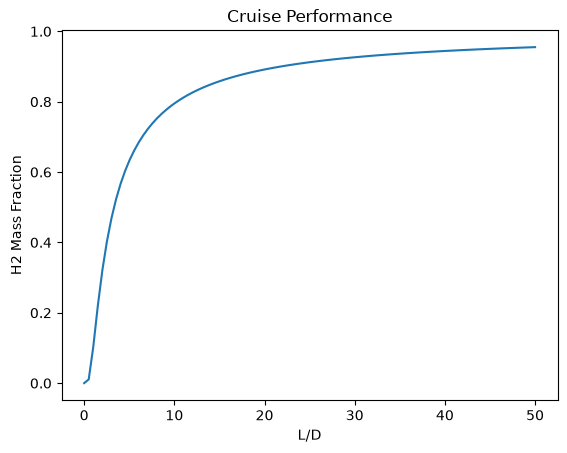

In [438]:
LD_crs = np.linspace(0, 50, 100) #Range of L/D values for cruise
H2_massfraction_cruise = np.exp((-range * (SFC_H2_exp_crs/10**6) * 9.8)/(M_crs_speed * 295.2 * LD_crs))

plt.plot(LD_crs, H2_massfraction_cruise)
plt.xlabel('L/D')
plt.ylabel('H2 Mass Fraction')
plt.title('Cruise Performance')
plt.show()
